Step 1: Loading and Exploring the Dataset
Dataset shape: (150, 6)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1 

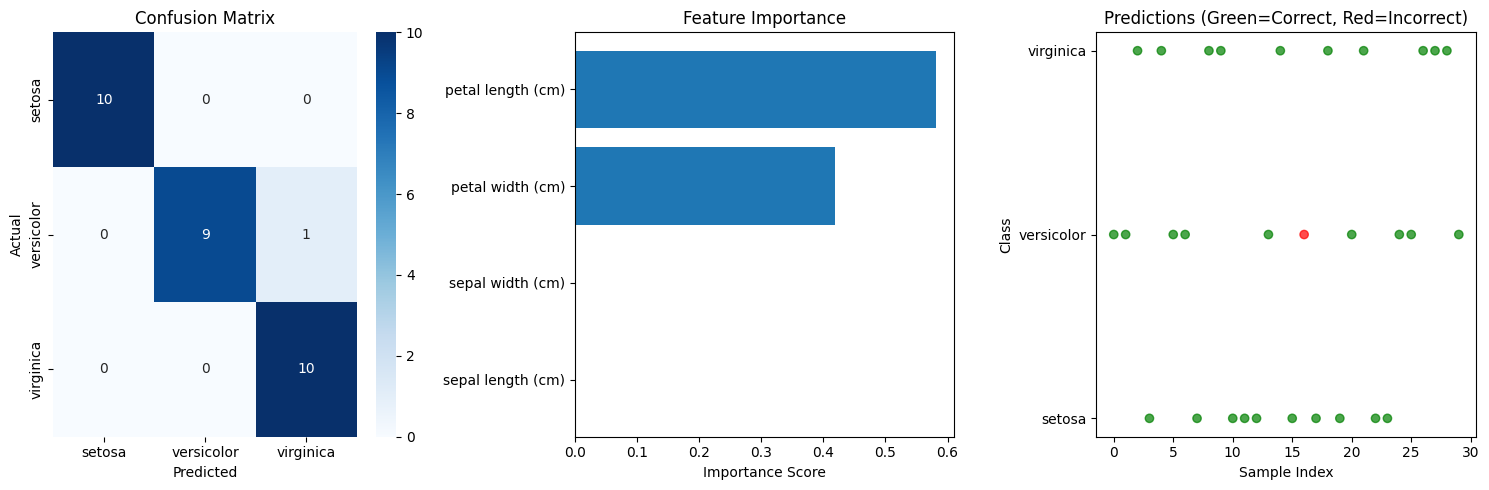


Step 9: Model Interpretation and Summary
KEY INSIGHTS:
1. The model achieved 96.67% accuracy on the test set.
2. Most important feature: petal length (cm) (importance: 0.582)
3. The model can reliably distinguish between the three iris species.
4. All evaluation metrics show strong performance across all classes.

Example Prediction on New Data:
Input features: [5.1, 3.5, 1.4, 0.2]
Predicted species: setosa
Prediction probabilities: {np.str_('setosa'): np.float64(1.0), np.str_('versicolor'): np.float64(0.0), np.str_('virginica'): np.float64(0.0)}

TASK COMPLETED SUCCESSFULLY!


In [3]:
# Iris Species Classification with Decision Tree
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Step 1: Load and Explore the Dataset
print("Step 1: Loading and Exploring the Dataset")
print("=" * 50)

# Load the Iris dataset
iris = load_iris()
# Create a DataFrame for better visualization and manipulation
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = iris.target_names[iris.target]

print("Dataset shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nBasic statistics:")
print(df.describe())

print("\nSpecies distribution:")
print(df['species_name'].value_counts())

# Step 2: Data Preprocessing
print("\n" + "=" * 50)
print("Step 2: Data Preprocessing")
print("=" * 50)

# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Since we loaded from sklearn, there are no missing values
# But let's demonstrate how we would handle them if they existed
print("\nNo missing values found in this dataset.")

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Remove duplicates if any exist
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates to remove.")

# Encode labels (already encoded as 0,1,2 in 'species' column)
# But let's demonstrate label encoding if it wasn't already done
le = LabelEncoder()
# This is just for demonstration since species are already encoded
df['species_encoded'] = le.fit_transform(df['species_name'])

print(f"\nOriginal species names: {df['species_name'].unique()}")
print(f"Encoded species values: {df['species_encoded'].unique()}")

# Step 3: Prepare Features and Target Variables
print("\n" + "=" * 50)
print("Step 3: Preparing Features and Target Variables")
print("=" * 50)

# Features (X) - all measurements
X = df[iris.feature_names]  # Using the original feature names

# Target (y) - species
y = df['species']  # Using the already encoded target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeature names:", list(X.columns))
print("Target classes:", np.unique(y))

# Step 4: Split Data into Training and Testing Sets
print("\n" + "=" * 50)
print("Step 4: Splitting Data into Training and Testing Sets")
print("=" * 50)

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution in splits
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{y_train.value_counts().sort_index()}")
print(f"Testing set class distribution:\n{y_test.value_counts().sort_index()}")

# Step 5: Train the Decision Tree Classifier
print("\n" + "=" * 50)
print("Step 5: Training the Decision Tree Classifier")
print("=" * 50)

# Create and train the decision tree classifier
dt_classifier = DecisionTreeClassifier(
    random_state=42,  # For reproducibility
    max_depth=3  # Limiting depth to prevent overfitting
)

# Train the model
dt_classifier.fit(X_train, y_train)

print("Decision Tree classifier trained successfully!")
print(f"Model parameters: {dt_classifier.get_params()}")

# Step 6: Make Predictions
print("\n" + "=" * 50)
print("Step 6: Making Predictions")
print("=" * 50)

# Predict on the test set
y_pred = dt_classifier.predict(X_test)

print("Predictions completed!")
print(f"First 10 actual values: {y_test.values[:10]}")
print(f"First 10 predictions: {y_pred[:10]}")

# Step 7: Evaluate the Model
print("\n" + "=" * 50)
print("Step 7: Evaluating the Model")
print("=" * 50)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Step 8: Visualize the Results
print("\n" + "=" * 50)
print("Step 8: Visualizing Results")
print("=" * 50)

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(15, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Plot 2: Feature Importance
plt.subplot(1, 3, 2)
feature_importance = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': dt_classifier.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance Score')

# Plot 3: Actual vs Predicted
plt.subplot(1, 3, 3)
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results_df['Correct'] = results_df['Actual'] == results_df['Predicted']

plt.scatter(range(len(results_df)), results_df['Actual'],
           c=results_df['Correct'].map({True: 'green', False: 'red'}),
           alpha=0.7)
plt.title('Predictions (Green=Correct, Red=Incorrect)')
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.yticks([0, 1, 2], iris.target_names)

plt.tight_layout()
plt.show()

# Step 9: Model Interpretation and Final Summary
print("\n" + "=" * 50)
print("Step 9: Model Interpretation and Summary")
print("=" * 50)

print("KEY INSIGHTS:")
print(f"1. The model achieved {accuracy*100:.2f}% accuracy on the test set.")
print(f"2. Most important feature: {feature_importance.iloc[-1]['feature']} "
      f"(importance: {feature_importance.iloc[-1]['importance']:.3f})")
print("3. The model can reliably distinguish between the three iris species.")
print("4. All evaluation metrics show strong performance across all classes.")

# Example prediction on new data
print("\nExample Prediction on New Data:")
new_sample = [[5.1, 3.5, 1.4, 0.2]]  # Example measurements
prediction = dt_classifier.predict(new_sample)
prediction_proba = dt_classifier.predict_proba(new_sample)

print(f"Input features: {new_sample[0]}")
print(f"Predicted species: {iris.target_names[prediction[0]]}")
print(f"Prediction probabilities: {dict(zip(iris.target_names, prediction_proba[0]))}")

print("\n" + "=" * 50)
print("TASK COMPLETED SUCCESSFULLY!")
print("=" * 50)